In [ ]:
import numpy as np

def objective(w1, w2, b):
    return 0.5 * (w1**2 + b * w2**2)

def grad(w1, w2, b):
    return w1, b * w2

def grad_norm(w1, w2, b):
    g1, g2 = grad(w1, w2, b)
    return np.sqrt(g1**2 + g2**2)

def gradient_descent(b, epsilon=1e-6, w_init=(1.0, 1.0), alpha=None, max_iters=100000):
    if alpha is None:
        alpha = 2.0 / (1.0 + b)

    w1, w2 = w_init
    k = 0

    while grad_norm(w1, w2, b) >= epsilon and k < max_iters:
        g1, g2 = grad(w1, w2, b)
        w1 = w1 - alpha * g1
        w2 = w2 - alpha * g2
        k += 1

    return (w1, w2), objective(w1, w2, b), k, epsilon, alpha

epsilon = 1e-6
for b in [1.0, 0.9, 0.1]:
    x_star, f_star, iters, eps_used, alpha_used = gradient_descent(
        b=b,
        epsilon=epsilon,
        w_init=(1.0, 1.0)
    )
    print(f"b = {b}")
    print(f"x* = ({x_star[0]:.8f}, {x_star[1]:.8f})")
    print(f"f(x*) = {f_star:.12e}")
    print(f"epsilon = {eps_used}")
    print(f"iterations = {iters}")
    print(f"alpha = {alpha_used:.6f}")
    print("-" * 40)

b = 1.0
x* = (0.00000000, 0.00000000)
f(x*) = 0.000000000000e+00
epsilon = 1e-06
iterations = 1
alpha = 1.000000
----------------------------------------
b = 0.9
x* = (-0.00000040, 0.00000040)
f(x*) = 1.549485782822e-13
epsilon = 1e-06
iterations = 5
alpha = 1.052632
----------------------------------------
b = 0.1
x* = (-0.00000097, 0.00000097)
f(x*) = 5.171760921967e-13
epsilon = 1e-06
iterations = 69
alpha = 1.818182
----------------------------------------


(a) Optimal solution w* = 1.0
(b) GD final w = 1.000000, first hit |w-1|<0.01: 29
(c) SGD const-step final w = 0.823389, first hit |w-1|<0.01: 66
(c) SGD decay-step final w = 1.085868, first hit |w-1|<0.01: None


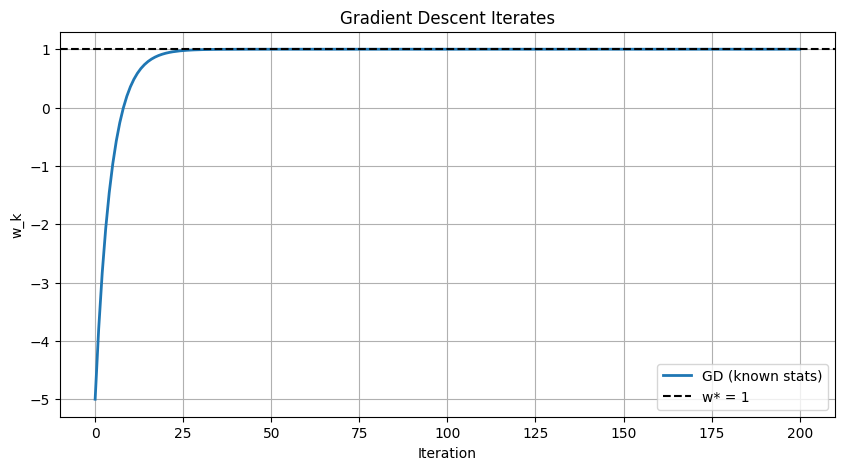

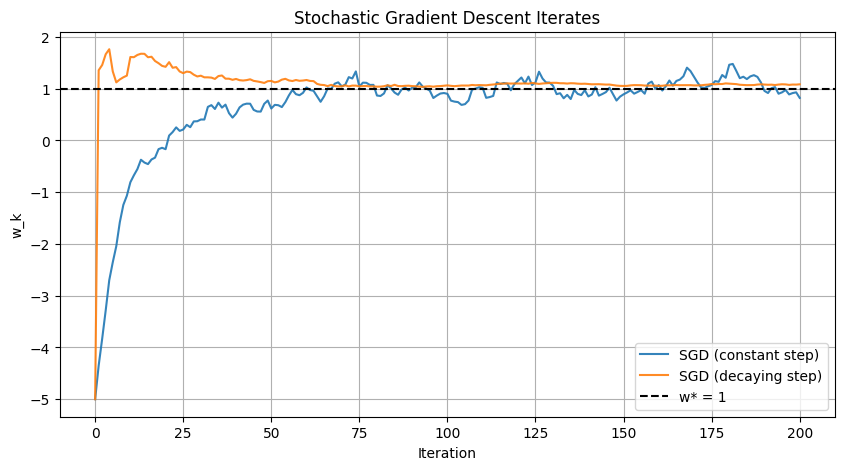

In [2]:
import numpy as np
import matplotlib.pyplot as plt

mu, sigma2 = 1.0, 1.0
sigma = np.sqrt(sigma2)

# (a) Optimal solution
w_star = mu
print(f"(a) Optimal solution w* = {w_star}")

# Common settings
K = 200
w0 = -5.0
tol = 1e-2
np.random.seed(42)

# -----------------------------
# (b) Gradient Descent (known mu, sigma^2)
# J(w) = (w-mu)^2 + sigma^2, grad = 2(w-mu)
# -----------------------------
eta_gd = 0.1
w_gd = np.zeros(K + 1)
w_gd[0] = w0

for k in range(K):
    grad = 2.0 * (w_gd[k] - mu)
    w_gd[k + 1] = w_gd[k] - eta_gd * grad

# -----------------------------
# (c) Stochastic Gradient Descent (unknown stats)
# use sample x_k ~ N(1,1), stochastic grad g_k = 2(w_k - x_k)
# -----------------------------
eta_sgd = 0.05 
w_sgd = np.zeros(K + 1)
w_sgd[0] = w0

for k in range(K):
    xk = np.random.normal(loc=1.0, scale=1.0)
    gk = 2.0 * (w_sgd[k] - xk)
    w_sgd[k + 1] = w_sgd[k] - eta_sgd * gk

a = 0.5
w_sgd_decay = np.zeros(K + 1)
w_sgd_decay[0] = w0

for k in range(K):
    xk = np.random.normal(loc=1.0, scale=1.0)
    eta_k = a / (k + 1)
    gk = 2.0 * (w_sgd_decay[k] - xk)
    w_sgd_decay[k + 1] = w_sgd_decay[k] - eta_k * gk

def first_hit(arr, target=1.0, threshold=1e-2):
    idx = np.where(np.abs(arr - target) < threshold)[0]
    return int(idx[0]) if len(idx) else None

hit_gd = first_hit(w_gd, w_star, tol)
hit_sgd = first_hit(w_sgd, w_star, tol)
hit_sgd_decay = first_hit(w_sgd_decay, w_star, tol)

print(f"(b) GD final w = {w_gd[-1]:.6f}, first hit |w-1|<{tol}: {hit_gd}")
print(f"(c) SGD const-step final w = {w_sgd[-1]:.6f}, first hit |w-1|<{tol}: {hit_sgd}")
print(f"(c) SGD decay-step final w = {w_sgd_decay[-1]:.6f}, first hit |w-1|<{tol}: {hit_sgd_decay}")

# -----------------------------
# Plots
# -----------------------------
iters = np.arange(K + 1)

plt.figure(figsize=(10, 5))
plt.plot(iters, w_gd, label="GD (known stats)", linewidth=2)
plt.axhline(w_star, color="k", linestyle="--", label="w* = 1")
plt.xlabel("Iteration")
plt.ylabel("w_k")
plt.title("Gradient Descent Iterates")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(iters, w_sgd, label="SGD (constant step)", alpha=0.9)
plt.plot(iters, w_sgd_decay, label="SGD (decaying step)", alpha=0.9)
plt.axhline(w_star, color="k", linestyle="--", label="w* = 1")
plt.xlabel("Iteration")
plt.ylabel("w_k")
plt.title("Stochastic Gradient Descent Iterates")
plt.legend()
plt.grid(True)
plt.show()

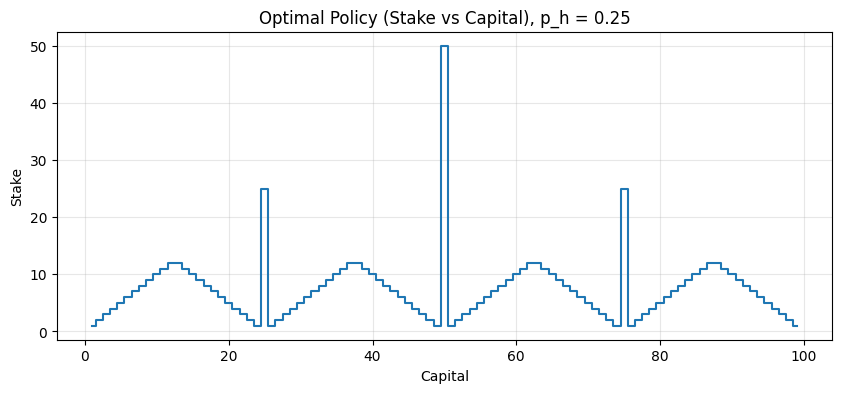

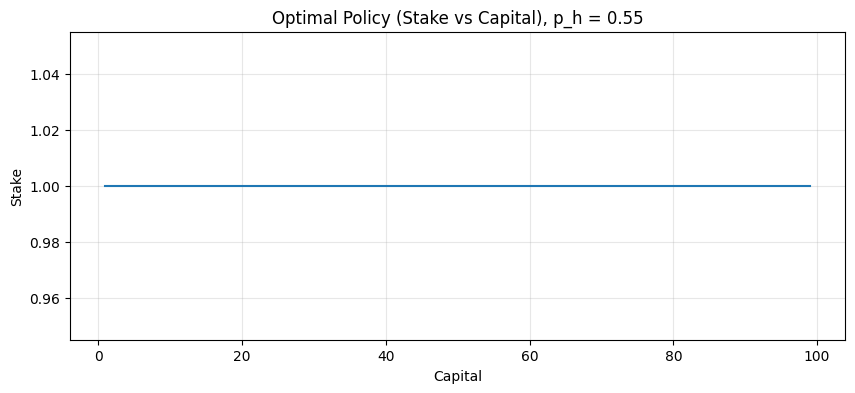

MC stopped after 200000 episodes


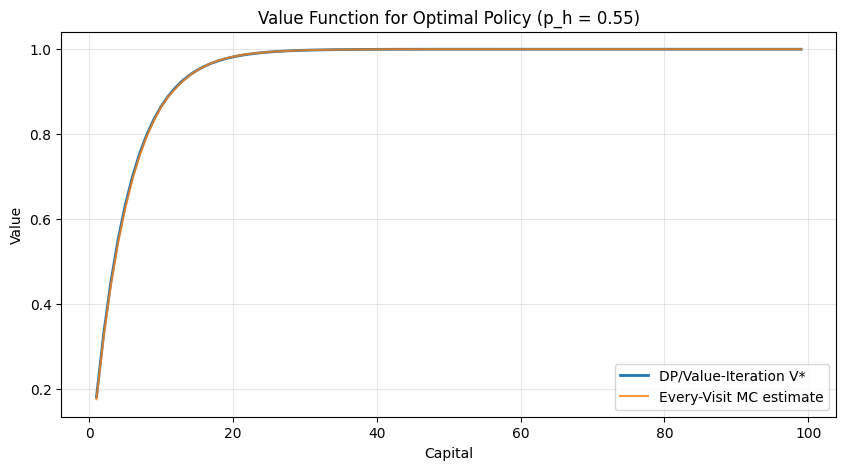

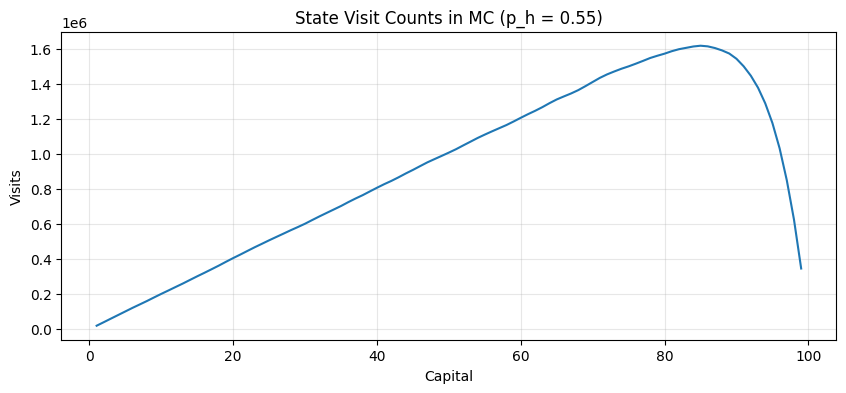

In [3]:
import numpy as np
import matplotlib.pyplot as plt

GOAL = 100

def value_iteration(ph, theta=1e-10, max_iter=100000):
    """
    Returns:
      V      : optimal state-value (size 101)
      policy : optimal stake for states 0..100 (policy[0]=policy[100]=0)
    Reward: +1 only when transition reaches GOAL.
    """
    V = np.zeros(GOAL + 1)          
    policy = np.zeros(GOAL + 1, dtype=int)

    for _ in range(max_iter):
        delta = 0.0
        for s in range(1, GOAL):
            actions = np.arange(1, min(s, GOAL - s) + 1) 
            action_values = []

            for a in actions:
                s_win = s + a
                s_lose = s - a
                r_win = 1.0 if s_win == GOAL else 0.0

                q = ph * (r_win + V[s_win]) + (1 - ph) * V[s_lose]
                action_values.append(q)

            best_v = np.max(action_values)
            delta = max(delta, abs(best_v - V[s]))
            V[s] = best_v

        if delta < theta:
            break

    for s in range(1, GOAL):
        actions = np.arange(1, min(s, GOAL - s) + 1)
        action_values = []

        for a in actions:
            s_win = s + a
            s_lose = s - a
            r_win = 1.0 if s_win == GOAL else 0.0
            q = ph * (r_win + V[s_win]) + (1 - ph) * V[s_lose]
            action_values.append(q)

        action_values = np.array(action_values)
        best = np.max(action_values)
        best_actions = actions[np.isclose(action_values, best, atol=1e-12)]
        policy[s] = best_actions[0]  

    return V, policy


def plot_policy(policy, ph):
    states = np.arange(1, GOAL)   
    plt.figure(figsize=(10, 4))
    plt.step(states, policy[1:GOAL], where='mid')
    plt.title(f"Optimal Policy (Stake vs Capital), p_h = {ph}")
    plt.xlabel("Capital")
    plt.ylabel("Stake")
    plt.grid(True, alpha=0.3)
    plt.show()


# Part (a): Value Iteration + policy plots for p_h = 0.25 and 0.55
V_025, pi_025 = value_iteration(ph=0.25)
V_055, pi_055 = value_iteration(ph=0.55)

plot_policy(pi_025, 0.25)
plot_policy(pi_055, 0.55)


# Part (c): Every-Visit Monte Carlo prediction for policy from p_h = 0.55
def generate_episode(policy, ph, start_state=None, max_steps=10000):
    """
    Episode under fixed policy.
    Returns lists of visited nonterminal states and rewards.
    """
    if start_state is None:
        s = np.random.randint(1, GOAL) 
    else:
        s = start_state

    states, rewards = [], []

    for _ in range(max_steps):
        if s == 0 or s == GOAL:
            break

        a = policy[s]
        if a == 0:
            a = 1

        if np.random.rand() < ph:
            s_next = s + a
            r = 1.0 if s_next == GOAL else 0.0
        else:
            s_next = s - a
            r = 0.0

        states.append(s)
        rewards.append(r)
        s = s_next

        if s == 0 or s == GOAL:
            break

    return states, rewards


def every_visit_mc_prediction(policy, ph, max_episodes=200000, min_episodes=5000,
                              check_every=5000, stop_tol=1e-4, seed=0):
    """
    Every-Visit MC for v_pi.
    Early stopping: if estimate changes very little over checkpoints.
    """
    rng_state = np.random.get_state()
    np.random.seed(seed)

    V_mc = np.zeros(GOAL + 1)
    N = np.zeros(GOAL + 1, dtype=int)

    prev_snapshot = V_mc.copy()
    stopped_at = max_episodes

    for ep in range(1, max_episodes + 1):
        states, rewards = generate_episode(policy, ph)

        # compute returns backward, gamma=1 (undiscounted episodic)
        G = 0.0
        for t in reversed(range(len(states))):
            G = rewards[t] + G
            s_t = states[t]

            # Every-visit update
            N[s_t] += 1
            V_mc[s_t] += (G - V_mc[s_t]) / N[s_t]

        # Optional early stop to avoid excessive runtime
        if ep % check_every == 0 and ep >= min_episodes:
            change = np.max(np.abs(V_mc - prev_snapshot))
            prev_snapshot = V_mc.copy()
            if change < stop_tol:
                stopped_at = ep
                break

    np.random.set_state(rng_state)
    return V_mc, N, stopped_at


V_mc_055, visit_counts, episodes_used = every_visit_mc_prediction(
    policy=pi_055,
    ph=0.55,
    max_episodes=200000,
    min_episodes=10000,
    check_every=5000,
    stop_tol=1e-4,
    seed=42
)

print(f"MC stopped after {episodes_used} episodes")

# Compare MC estimate with DP value (from value iteration) for p_h=0.55
states = np.arange(1, GOAL)

plt.figure(figsize=(10, 5))
plt.plot(states, V_055[1:GOAL], label="DP/Value-Iteration V*", linewidth=2)
plt.plot(states, V_mc_055[1:GOAL], label="Every-Visit MC estimate", alpha=0.8)
plt.title("Value Function for Optimal Policy (p_h = 0.55)")
plt.xlabel("Capital")
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(states, visit_counts[1:GOAL])
plt.title("State Visit Counts in MC (p_h = 0.55)")
plt.xlabel("Capital")
plt.ylabel("Visits")
plt.grid(True, alpha=0.3)
plt.show()

NOTE: Ties were broken by choosing smallest optimal stake. If tie is broken by choosing largest optimal stake, the policy would be more aggressive.

For \(p_h = 0.25\), the policy looks spiky because ties are broken by choosing the smallest optimal stake.  
So the agent often picks small bets, with occasional sharp jumps at states where a larger stake is clearly better.  

For \(p_h = 0.55\), the policy is generally more stable and less extreme, since the coin is favorable and steady progress to the goal is effective.

(c)  
In the Monte Carlo evaluation (\(p_h = 0.55\)), episodes can still be long and state visitation is uneven, so some state-value estimates converge slowly.  
Early stopping is used as a practical runtime/convergence trade-off once changes in the value estimates become very small.